# 05. Qual vendedor teve o melhor desempenho nos ultimos 5 anos

Janela: 2020 a 2024. Base: vendas limpas dos notebooks anteriores.

In [1]:
import pandas as pd
from pathlib import Path
from cristalux.config import settings
from cristalux.cleaning import parsers as p
from cristalux.cleaning.base import ler_csv
from cristalux.pipeline.run import ARQUIVOS, limpar_tudo, relatorio_qualidade

pd.set_option("display.width", 200, "display.max_columns", 40, "display.max_rows", 200, "display.max_colwidth", 60)
raws, res = limpar_tudo(settings.data_dir)

In [2]:
import matplotlib.pyplot as plt
v = res["vendas"].clean
vend = res["vendedores"].clean.set_index("id_vendedor")
INI, FIM = pd.Timestamp("2020-01-01"), pd.Timestamp("2024-12-01")


def meses_de_atuacao(id_vendedor):
    """Meses entre a admissao (ou jan/2020) e dez/2024."""
    adm = vend.loc[id_vendedor, "data_admissao"]
    inicio = max(INI, pd.Timestamp(adm).replace(day=1)) if pd.notna(adm) else INI
    return (FIM.year - inicio.year) * 12 + FIM.month - inicio.month + 1


def ranking(df):
    g = df.groupby("id_vendedor").agg(faturamento=("valor_total", "sum"), vendas=("id_venda", "count"))
    g["ticket_medio"] = g["faturamento"] / g["vendas"]
    g["meses_atuacao"] = [meses_de_atuacao(i) for i in g.index]
    g["fat_por_mes"] = g["faturamento"] / g["meses_atuacao"]
    g["atingimento_meta"] = g["faturamento"] / (vend.loc[g.index, "meta_mensal"] * g["meses_atuacao"])
    g.insert(0, "vendedor", vend.loc[g.index, "nome"])
    return g.sort_values("faturamento", ascending=False)

base = ranking(v[v["status"] == "concluida"])
base.round(2)

,vendedor,faturamento,vendas,ticket_medio,meses_atuacao,fat_por_mes,atingimento_meta
id_vendedor,,,,,,,
V007,Gabriela Rocha,216682.61,5,43336.52,56,3869.33,0.08
V003,Carla Mendonça,112280.58,5,22456.12,60,1871.34,0.04
V017,Queila Barbosa,98965.84,2,49482.92,7,14137.98,0.40
V010,João Pedro Lima,92488.87,2,46244.44,30,3082.96,0.08
V002,Bruno Alves,91768.76,3,30589.59,55,1668.52,0.03
V008,Henrique Souza,80293.72,2,40146.86,56,1433.82,0.03
V016,Pedro Henrique,58199.16,1,58199.16,60,969.99,0.02
V012,Leonardo Bastos,51136.46,2,25568.23,50,1022.73,0.03
V001,Ana Paula Ferreira,38049.48,1,38049.48,60,634.16,0.01


## Metrica adotada: faturamento de vendas concluidas

Faturamento = soma de `valor_total` (quantidade x preco, como a origem reporta) das vendas com status concluida entre 2020 e 2024.
O faturamento liquido de desconto (`valor_liquido`) e usado como checagem.

Por que essa metrica:

- **E receita realizada.** Cancelada, devolvida e pendente nao viraram receita; contar essas inflaria o resultado.
- **Segue o total da origem.** O `valor_total` informado ja confere com quantidade x preco em 84 das 96 linhas validas. O desconto e conferido a parte, e nao muda o resultado (ver abaixo).
- **Reflete o periodo inteiro.** O enunciado pede os ultimos 5 anos, nao o ultimo mes.

Metricas complementares (para checar se o resultado se sustenta): numero de vendas, ticket medio, faturamento por mes de atuacao
(corrige quem entrou depois de 2020) e atingimento da meta (faturamento dividido pela meta mensal vezes os meses de atuacao).

In [3]:
melhor = base.index[0]
print("Melhor vendedor:", base.loc[melhor, "vendedor"], f"({melhor})")
print(f"Faturamento: R$ {base.loc[melhor, 'faturamento']:,.2f} em {int(base.loc[melhor, 'vendas'])} vendas")

Melhor vendedor: Gabriela Rocha (V007)
Faturamento: R$ 216,682.61 em 5 vendas


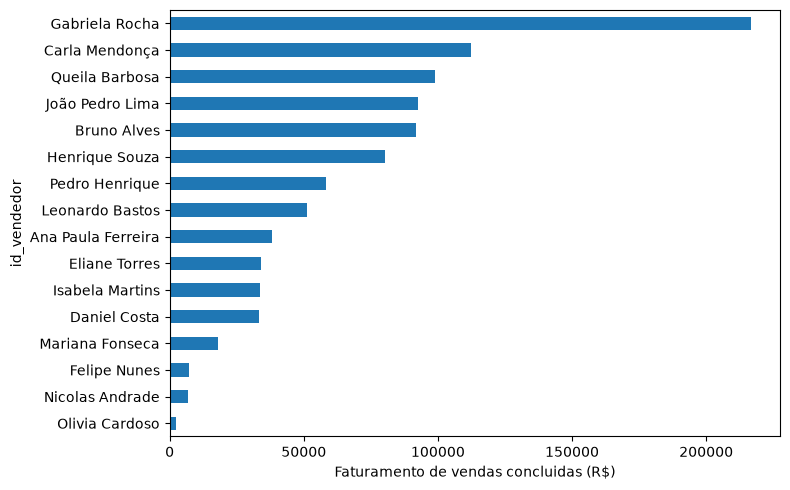

In [4]:
ax = base["faturamento"].sort_values().plot.barh(figsize=(8, 5))
ax.set_yticklabels(base.sort_values("faturamento")["vendedor"])
ax.set_xlabel("Faturamento de vendas concluidas (R$)")
plt.tight_layout(); plt.show()

## O resultado se sustenta?

O primeiro lugar sob cada metrica e cada regra alternativa de filtro:

In [5]:
cenarios = {
    "faturamento (adotada)": base["faturamento"],
    "numero de vendas": base["vendas"],
    "ticket medio": base["ticket_medio"],
    "faturamento por mes de atuacao": base["fat_por_mes"],
    "atingimento da meta": base["atingimento_meta"],
}
antes = lambda f: "venda_antes_da_admissao" in f
alternativas = {
    "faturamento liquido de desconto": ranking(v[v["status"] == "concluida"].assign(valor_total=lambda d: d["valor_liquido"]))["faturamento"],
    "incluindo pendentes": ranking(v[v["status"].isin(["concluida", "pendente"])])["faturamento"],
    "todas as vendas validas": ranking(v)["faturamento"],
    "sem vendas anteriores a admissao": ranking(v[(v["status"] == "concluida") & ~v["flags"].map(antes)])["faturamento"],
}
linhas = []
for nome, serie in {**cenarios, **alternativas}.items():
    top = serie.sort_values(ascending=False)
    linhas.append({"criterio": nome, "primeiro": vend.loc[top.index[0], "nome"], "segundo": vend.loc[top.index[1], "nome"]})
pd.DataFrame(linhas)

,criterio,primeiro,segundo
0,faturamento (adotada),Gabriela Rocha,Carla Mendonça
1,numero de vendas,Gabriela Rocha,Carla Mendonça
2,ticket medio,Pedro Henrique,Queila Barbosa
3,faturamento por mes de atuacao,Queila Barbosa,Gabriela Rocha
4,atingimento da meta,Queila Barbosa,Gabriela Rocha
5,faturamento liquido de desconto,Gabriela Rocha,Carla Mendonça
6,incluindo pendentes,Gabriela Rocha,Daniel Costa
7,todas as vendas validas,Gabriela Rocha,Bruno Alves
8,sem vendas anteriores a admissao,Carla Mendonça,Gabriela Rocha


Leitura do quadro acima:

- Sob a metrica adotada, Gabriela Rocha lidera, com Carla Mendonca em segundo. O mesmo vale para o faturamento liquido de desconto, para o numero de vendas e para "todas as vendas validas".
- **Ticket medio** premia quem tem uma unica venda grande (1 a 5 vendas por vendedor): so serve de apoio.
- **Faturamento por mes de atuacao** e **atingimento da meta** colocam Queila Barbosa na frente, mas isso e um artefato: ela foi admitida em 06/2024 e as duas vendas atribuidas a ela sao de 2020 e 2021 (flag `venda_antes_da_admissao`). Dividir por apenas 7 meses de atuacao infla o resultado.
- **Incluindo pendentes**, Gabriela continua na frente (Daniel Costa passa a segundo). Pendente ainda nao e receita, entao fica fora da metrica, mas o resultado nao depende dessa escolha.
- **Sem vendas anteriores a admissao**, Carla Mendonca assume o primeiro lugar. Varias vendas de Gabriela estao em 15/01/2020, antes da admissao dela (05/2020).

In [6]:
base["fat_pre_admissao"] = [
    v[(v["id_vendedor"] == i) & (v["status"] == "concluida") & v["flags"].map(antes)]["valor_total"].sum() for i in base.index]
base["%_pre_admissao"] = (100 * base["fat_pre_admissao"] / base["faturamento"]).round(0)
base[["vendedor", "faturamento", "fat_pre_admissao", "%_pre_admissao"]].head(6).round(2)

,vendedor,faturamento,fat_pre_admissao,%_pre_admissao
id_vendedor,,,,
V007,Gabriela Rocha,216682.61,123237.56,57.0
V003,Carla Mendonça,112280.58,0.00,0.0
V017,Queila Barbosa,98965.84,98965.84,100.0
V010,João Pedro Lima,92488.87,77776.12,84.0
V002,Bruno Alves,91768.76,39884.68,43.0
V008,Henrique Souza,80293.72,69765.00,87.0


## Conclusao e limites

**Gabriela Rocha (V007)** e o melhor vendedor pela metrica adotada: R$ 217 mil de faturamento em vendas concluidas, 5 vendas,
quase o dobro do segundo colocado.

O resultado tem duas fragilidades que precisam ficar claras:

- **Datas contra cadastro.** 57% do faturamento de Gabriela (cerca de R$ 124 mil de R$ 217 mil) vem de vendas anteriores a admissao dela, enquanto Carla Mendonca nao tem nenhuma venda nessa situacao. O erro pode estar na data da venda ou na data de admissao e os dados nao permitem saber qual. Se essas vendas fossem descartadas, Carla Mendonca passaria a frente. A decisao foi manter e sinalizar.
- **Amostra pequena.** A base limpa tem 33 vendas concluidas, de 1 a 5 por vendedor, e cerca de metade das linhas de `vendas` foi rejeitada na limpeza. Uma venda a mais ou a menos pode mudar posicoes.

Em resumo: a resposta e Gabriela Rocha, com a ressalva de que a lideranca depende de como se trata o conflito entre datas de venda e de admissao.

## Conferencia com o banco

In [7]:
try:
    from cristalux.db.setup import conectar
    with conectar() as conn, conn.cursor() as cur:
        cur.execute("SELECT vendedor, SUM(faturamento) f FROM clean.vw_faturamento_mensal_vendedor GROUP BY vendedor ORDER BY f DESC LIMIT 3")
        print(cur.fetchall())
except Exception as e:
    print("banco indisponivel:", type(e).__name__)

[('Gabriela Rocha', Decimal('216682.61')), ('Carla Mendonça', Decimal('112280.58')), ('Queila Barbosa', Decimal('98965.84'))]
